# 📊 EDA — IoT-Integrated Predictive Maintenance Dataset

## Objetivo
Explorar o dataset de manutenção preditiva baseado em sensores IoT para entender:
- Estrutura geral dos dados (linhas, colunas, tipos)
- Comportamento das variáveis de sensores ao longo do tempo
- Qualidade dos dados (valores ausentes, outliers)
- Distribuição da variável-alvo (falha vs. não-falha)

## Dataset
- **Fonte:** https://www.kaggle.com/datasets/ziya07/iot-integrated-predictive-maintenance-dataset/data


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../data/predictive_maintenance_dataset.csv')
df.head()

,timestamp,machine_id,vibration,acoustic,temperature,current,IMF_1,IMF_2,IMF_3,label
0,2024-07-01 08:00:00,M01,0.822,0.645,66.85,13.04,0.196,0.033,0.000,0
1,2024-07-01 08:01:00,M01,1.398,0.834,76.20,15.08,0.345,0.132,0.001,1
2,2024-07-01 08:02:00,M01,0.856,0.590,67.03,12.30,0.187,0.017,0.002,0
3,2024-07-01 08:03:00,M01,0.793,0.544,65.04,11.69,0.196,-0.060,0.003,0
4,2024-07-01 08:04:00,M01,1.279,0.721,78.19,14.84,0.330,-0.115,0.004,1


## 2. Estrutura Geral dos Dados

**Perguntas:**
- Quantas linhas e colunas temos?
- Quais os tipos de cada variável (numérica, categórica, data)?

In [11]:
print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")
df.info()


Linhas: 1800 | Colunas: 10
<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   timestamp    1800 non-null   str    
 1   machine_id   1800 non-null   str    
 2   vibration    1800 non-null   float64
 3   acoustic     1800 non-null   float64
 4   temperature  1800 non-null   float64
 5   current      1800 non-null   float64
 6   IMF_1        1800 non-null   float64
 7   IMF_2        1800 non-null   float64
 8   IMF_3        1800 non-null   float64
 9   label        1800 non-null   int64  
dtypes: float64(7), int64(1), str(2)
memory usage: 140.8 KB


In [12]:
df.duplicated().sum()

np.int64(0)

## 3. Estatísticas Descritivas

**Pergunta:** Quais são as variáveis de sensores (vibração, temperatura, corrente etc.) e qual a faixa típica de valores de cada uma?

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
vibration,1800.0,0.843295,0.136690,0.645,0.769,0.8050,0.85100,1.405
acoustic,1800.0,0.633898,0.107989,0.430,0.572,0.6090,0.65125,1.083
temperature,1800.0,66.355722,4.448129,58.360,63.730,65.3550,66.99000,85.160
current,1800.0,12.328600,1.094510,10.290,11.700,12.0800,12.48000,16.940
IMF_1,1800.0,0.168738,0.056533,0.073,0.123,0.1660,0.20700,0.393
IMF_2,1800.0,0.000072,0.073104,-0.180,-0.058,-0.0010,0.05900,0.187
IMF_3,1800.0,0.000673,0.036034,-0.050,-0.037,0.0035,0.03700,0.050
label,1800.0,0.112222,0.315727,0.000,0.000,0.0000,0.00000,1.000


## 4. Dados Faltantes

**Pergunta:** Temos valores ausentes? Em quais colunas? Eles se concentram em algum período de tempo específico?

In [4]:
df.isnull().sum().sort_values(ascending=False)

timestamp      0
machine_id     0
vibration      0
acoustic       0
temperature    0
current        0
IMF_1          0
IMF_2          0
IMF_3          0
label          0
dtype: int64

## 5. Comportamento dos Sensores ao Longo do Tempo

**Pergunta:** Como cada sensor se comporta ao longo do tempo? Existem padrões visuais que antecedem falhas?

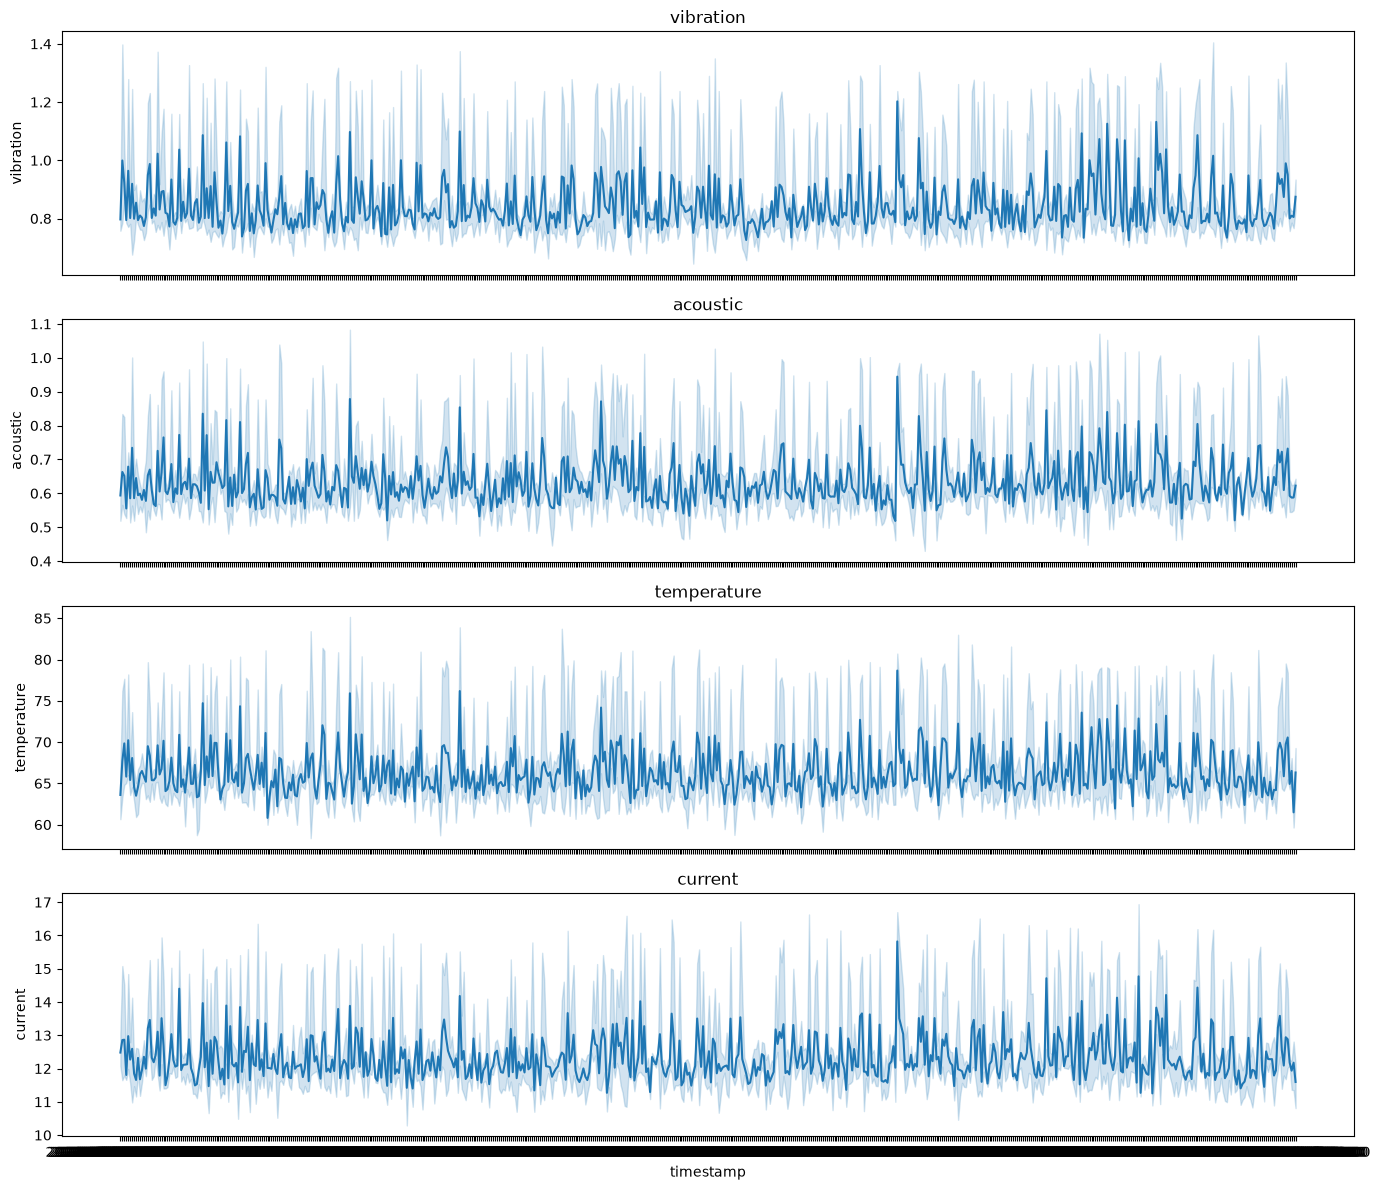

In [7]:
# Ajustar 'timestamp' e as colunas de sensores conforme o dataset real
sensor_cols = ['vibration', 'acoustic', 'temperature', 'current']
fig, axes = plt.subplots(len(sensor_cols), 1, figsize=(14, 3*len(sensor_cols)), sharex=True)

for ax, col in zip(axes, sensor_cols):
    sns.lineplot(data=df, x='timestamp', y=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

## 6. Primeiras Observações

**Resumo do que foi encontrado:**
- Dataset com 1.800 linhas e 10 colunas, sem nenhum valor ausente — dados já vêm limpos.
- 4 sensores brutos: `vibration`, `acoustic`, `temperature`, `current`, além de 3 variáveis derivadas (`IMF_1`, `IMF_2`, `IMF_3`), que parecem ser componentes extraídos do sinal de vibração via decomposição (Intrinsic Mode Functions), não sensores originais.
- Granularidade temporal de 1 minuto (`timestamp` sequencial a partir de 2024-07-01 08:00:00).
- Variável-alvo `label` é binária (0 = normal, 1 = falha), com média de ~0.112 → **dataset desbalanceado**, cerca de 11% das observações são falhas. Isso vai exigir cuidado na modelagem (métricas como F1/recall/AUC-PR em vez de acurácia, e possivelmente técnicas de balanceamento como SMOTE ou class_weight).


**Hipóteses iniciais sobre sensores relevantes:**
- Todos os sensores (`vibration`, `acoustic`, `temperature`, `current`) mostram picos frequentes e irregulares ao longo do tempo, sugerindo eventos transitórios (possivelmente correlacionados com falhas).
- `vibration` e `acoustic` parecem ter maior variabilidade relativa (desvio padrão alto em relação à média), o que é consistente com a literatura de manutenção preditiva — vibração costuma ser um dos indicadores mais sensíveis a degradação mecânica.
- Ainda não sei se os picos coincidem temporalmente com `label = 1` — próximo passo natural é sobrepor as falhas nos gráficos de linha (ex: marcar em vermelho os pontos onde `label == 1`).

**Próximos passos → Fase 2 (limpeza e engenharia de atributos):**
- [ ] Verificar duplicatas e outliers com mais rigor (boxplots por sensor)
- [ ] Cruzar `label` com os sensores: comparar distribuição de cada sensor em falha vs. não-falha (`sns.boxplot` ou `sns.violinplot` com `hue='label'`)
- [ ] Checar `machine_id`: uma ou várias máquinas?
- [ ] Analisar correlação entre sensores (`df.corr()` + heatmap) — inclusive entre os sensores brutos e os IMFs
- [ ] Criar features de janela (médias móveis, desvio padrão móvel) já pensando na Fase 2